# Relationship between demand and tasmax

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
#from xhistogram.xarray import histogram

import matplotlib.pyplot as plt

In [3]:
# from workalendar.registry import registry

In [4]:
# registry.get_subregions(region)[region + "-" + subregion]()

In [5]:
# def select_workday(da, calendar, drop=False):
#     """
#     Remove weekends and public holidays
    
#     da: array
#     calendar: None, or calendar from registry
#     drop: bool, whether to drop NaNs
#     """
#     is_workday = [calendar.is_working_day(pd.to_datetime(i)) for i in da["time"].values]
#     da = da.assign_coords({"is_workday": ("time", is_workday)})
#     return da.where(da.is_workday == True, drop=drop)

### Load data

In [2]:
demand = pd.read_csv(
    "/home/565/ad1803/Hot_Cloudy/Demand/input_data/hourly_demand_20090701-20231230.csv",
    index_col=0,
    parse_dates=True
)

In [3]:
demand["NEM"] = demand.sum(axis=1)
# AD: demand["NEM"] creates a new column in the pd data frame called NEM, where it creates the sum across all regions for each row
demand 

,NSW,QLD,SA,TAS,VIC,NEM
SETTLEMENTDATE,,,,,,
2009-07-01 00:00:00,9811.083333,6319.625000,1694.600833,1359.704167,6737.801667,25922.815000
2009-07-01 01:00:00,9518.105000,6201.692500,1715.465000,1293.429167,6679.405000,25408.096667
2009-07-01 02:00:00,9362.036667,6183.130833,1686.535833,1279.117500,6602.611667,25113.432500
2009-07-01 03:00:00,9228.744167,6156.053333,1695.395833,1265.324167,6730.846667,25076.364167
2009-07-01 04:00:00,9131.188333,6155.266667,1677.635833,1301.748333,6599.993333,24865.832500
2009-07-01 05:00:00,9073.065833,6146.474167,1646.598333,1316.406667,6494.703333,24677.248333
2009-07-01 06:00:00,9382.911667,6217.885000,1679.749167,1368.024167,6562.645000,25211.215000
2009-07-01 07:00:00,10524.949167,6582.785000,1808.895833,1433.537500,7034.595833,27384.763333
2009-07-01 08:00:00,10944.614167,6677.454167,2005.838333,1427.793333,7188.710833,28244.410833


Convert to xarray dataset

In [4]:
demand = xr.DataArray(
    demand.transpose(),
    dims=["region", "time"],
    coords={"region": demand.columns, "time": demand.index.values}
)


Convert to AEST for ease of interpretation

In [6]:
#demand["time"] = demand["SETTLEMENTDATE"]
demand["time"] = pd.to_datetime(demand["SETTLEMENTDATE"].values) #AD: turns a pandas dataframe into datetime, specifically the time column 
demand["time"] = [i + pd.DateOffset(hours=10) for i in demand.time.values]

KeyError: 'SETTLEMENTDATE'

In [7]:
demand["time"]

<xarray.DataArray 'time' (time: 127104)>
array(['2009-07-01T00:00:00.000000000', '2009-07-01T01:00:00.000000000',
       '2009-07-01T02:00:00.000000000', ..., '2023-12-30T21:00:00.000000000',
       '2023-12-30T22:00:00.000000000', '2023-12-30T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2009-07-01 ... 2023-12-30T23:00:00

In [8]:
tasmax = xr.open_mfdataset(
    "/home/565/ad1803/Hot_Cloudy/Demand/output_data/barra/*.nc",
)

In [9]:
tasmax = tasmax.sel(time=slice("2009-07-01", "2023-12-30"))

In [10]:
tasmax = tasmax.tasmax.compute()

In [11]:
tasmax

<xarray.DataArray 'tasmax' (time: 127104, region: 6)>
array([[288.603282, 289.202849, 285.410099, 293.081129, 286.151506,
        283.091343],
       [289.669042, 290.267057, 286.309652, 294.592686, 286.868028,
        283.014034],
       [290.356654, 290.960744, 286.784801, 295.706116, 287.379585,
        282.626015],
       ...,
       [292.226441, 292.014028, 288.566914, 298.989197, 288.277879,
        287.88682 ],
       [293.379041, 292.772819, 289.660042, 300.510465, 290.224683,
        289.642972],
       [294.474121, 293.539709, 290.783631, 301.823832, 291.91691 ,
        291.367592]])
Coordinates:
    height   float64 1.5
    crs      int32 0
  * region   (region) object u'NEM' u'NSW' u'VIC' u'QLD' u'SA' u'TAS'
  * time     (time) datetime64[ns] 2009-07-01T00:30:00 ... 2023-12-30T23:30:00

BARRA timestamps are every half hour. Set them back half an hour to align with demand.

In [12]:
tasmax["time"] = demand["time"]

Kelvin to Celsius

In [13]:
tasmax = tasmax - 273.15

Re-order demand region dimension to match tasmax

In [14]:
demand = demand.sel(region=tasmax.region.values)

#### Hour of maximum daily values

In [27]:
def hour_of_max(ds):
    """
    Return the hour of daily maximum
    
    da: dataset
    """
    def idxmax(da):
        return da.idxmax("time")
    ds = ds.assign_coords(hour=("time", ds.time.dt.hour.values))
    group = ds.groupby("time.date")
    return group.map(idxmax)

In [16]:
def hour_hist(da):
    """
    Return histogram
    
    da: DataArray
    """
    bins = np.linspace(0, 24, 25)
    return histogram(da, bins=[bins])

In [17]:
def plot_hists(ds1, ds2):
    """
    Plot histograms of hourly maxima of ds1 and ds2 for each region
    
    ds1, ds2: dataarrays
    """
    fig, ax = plt.subplots(2, 3, figsize=(7, 4))
    
    for i, r in enumerate(ds1.region.values):
        d1 = ds1.sel(region=r)
        d2 = ds2.sel(region=r)
        
        h1 = hour_hist(d1.hour)
        h2 = hour_hist(d2.hour)
        
        h1.plot(ax=ax.flatten()[i], label="Demand")
        h2.plot(ax=ax.flatten()[i], label="Tasmax")
        ax.flatten()[i].set_title(r)
        
        if i in [0, 3]:
            ax.flatten()[i].set_ylabel("Count [days]")
        else:
            ax.flatten()[i].set_ylabel("")
        if i > 2:
            ax.flatten()[i].set_xlabel("AEST [hour]")
        else:
            ax.flatten()[i].set_xlabel("")
            
        if i == 0:
            ax.flatten()[i].legend()
    
    plt.tight_layout()

In [28]:
demand_max_hour = hour_of_max(demand)

AttributeError: 'DatetimeAccessor' object has no attribute 'date'

In [22]:
tasmax_max_hour = hour_of_max(tasmax)

AttributeError: 'DataArrayGroupBy' object has no attribute 'map'

### Hour of maximum demand and tasmax
Note that this is AEST, so summertime maxima happen an hour earlier in AEDT

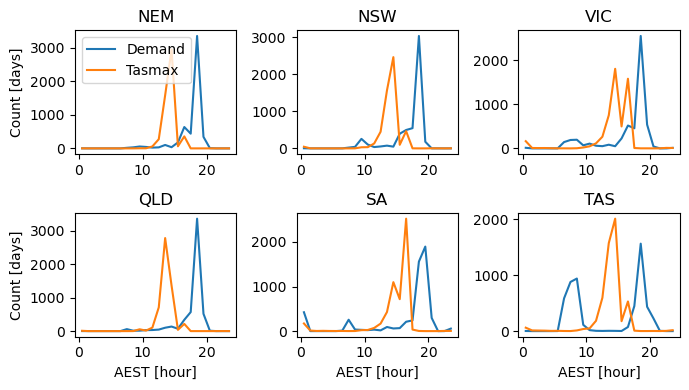

In [211]:
plot_hists(demand_max_hour.hour, tasmax_max_hour.hour)

### Time series

In [40]:
def plot_ts(ds, ylabel):
    """
    Plot time series of ds for each region
    
    ds: dataarray
    ylabel: str, ylabel
    """
    fig, ax = plt.subplots(2, 3, figsize=(7, 4))
    
    for i, r in enumerate(ds.region.values):
        d = ds.sel(region=r)
        
        d.plot(ax=ax.flatten()[i])
        ax.flatten()[i].set_title(r)
        ax.flatten()[i].tick_params(axis='x', labelrotation=40)
        
        if i in [0, 3]:
            ax.flatten()[i].set_ylabel(ylabel)
        
    plt.tight_layout()

Daily maximum

In [41]:
demand_dmax = demand.resample(time="1D").max()

In [42]:
tasmax_dmax = tasmax.resample(time="1D").max()

Strange trends in demand, not due to weather. Possibly should remove these as in paper.

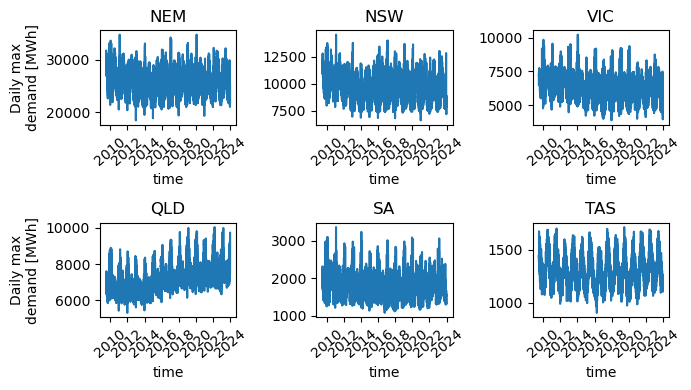

In [18]:
plot_ts(demand_dmax, ylabel="Daily max\ndemand [MWh]")

No obvious trends in tasmax

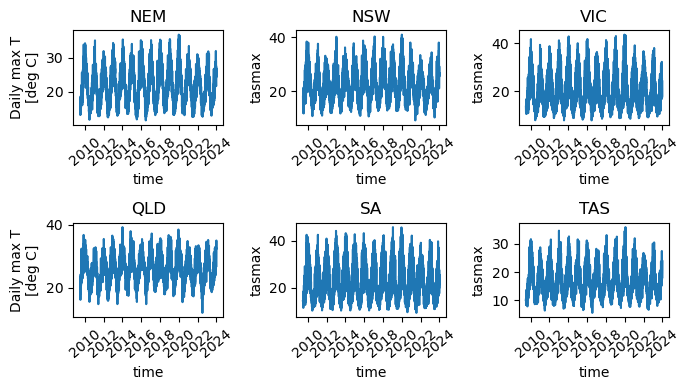

In [19]:
plot_ts(tasmax_dmax, ylabel="Daily max T\n[deg C]")

### Relationships

Day of week

In [43]:
def day_of_week_num(dts):
    """
    dts: array of datetime64
    
    From https://stackoverflow.com/a/54264187
    """
    # Monday is day 0
    return (dts.astype('datetime64[D]').view('int64') - 4) % 7

In [97]:
tasmax_dmax = tasmax_dmax.assign_coords(dayofweek=("time", day_of_week_num(tasmax_dmax.time.values)))

In [99]:
demand_dmax = demand_dmax.assign_coords(dayofweek=("time", day_of_week_num(demand_dmax.time.values)))

In [104]:
def plot_scatter(xds, yds, add_weekend=True):
    """
    Scatter xds against yds
    
    xds, yds: datasets to plot
    add_weekend: also plot weekend
    """
    fig, ax = plt.subplots(2, 3, figsize=(7, 4))
    
    for i, r in enumerate(xds.region.values):
        xd = xds.where(xds.dayofweek < 5).dropna("time").sel(region=r)
        yd = yds.where(yds.dayofweek < 5).dropna("time").sel(region=r)
        
        ax.flatten()[i].scatter(xd, yd, color="tab:blue", alpha=0.5, s=5, label="Weekday")
        
        if add_weekend:
            xd_wknd = xds.where(xds.dayofweek >= 5).dropna("time").sel(region=r)
            yd_wknd = yds.where(yds.dayofweek >= 5).dropna("time").sel(region=r)
            
            ax.flatten()[i].scatter(xd_wknd, yd_wknd, color="tab:orange", alpha=0.5, s=5, label="Weekend")
        
        ax.flatten()[i].set_title(r)
        ax.flatten()[i].tick_params(axis='x', labelrotation=40)
        
        if r == "TAS":
            xq = xd.quantile(0.01, "time")
            ax.flatten()[i].axvline(xq, c="k")
        else:
            xq = xd.quantile(0.99, "time")
            ax.flatten()[i].axvline(xq, c="k")
        
        yq = yd.quantile(0.99, "time")
        ax.flatten()[i].axhline(yq, c="k")
        
        if i > 2:
            ax.flatten()[i].set_xlabel("Daily max T [deg C]")
        if i in [0, 3]:
            ax.flatten()[i].set_ylabel("Daily max\ndemand [MWh]")
        
    plt.tight_layout()

#### Demand vs tasmax
Lines show 99th percentiles of demand and tasmax (1st percentile T for TAS)

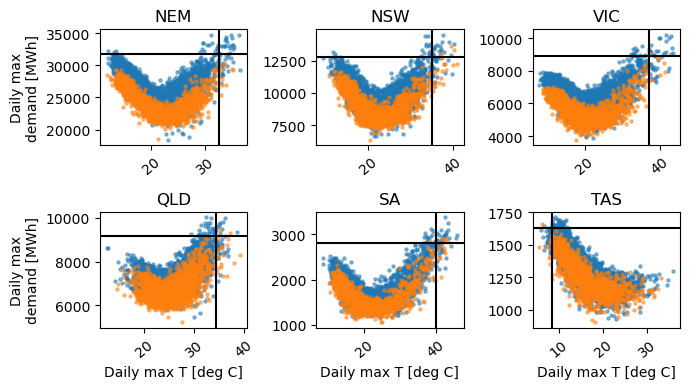

In [105]:
plot_scatter(tasmax_dmax, demand_dmax)